# Tutorial 2. De dónde salen los datos

PE1333 Machine Learning para Economistas. Maestría en Economía, UdeSA. 8 de octubre de 2026.

En el paper de Cavallo la base se arma de dos maneras. Una mitad la juntan 323 personas que van a
un local, escanean un código de barras y fotografían la etiqueta. La otra mitad la junta un
programa que entra al sitio de la misma cadena y levanta el precio.

Hoy hacemos la mitad barata, que tiene dos variantes bien distintas:

- **Una API**, cuando los datos están publicados a propósito para que un programa los lea.
- **Web scraping**, cuando hay que sacarlos de una página que no fue pensada para eso.

Antes de eso, cerramos lo que quedó pendiente de la clase pasada.

Para correrlo entero: `Kernel` → `Restart & Run All`.

## 1. Lo que quedó de la clase pasada

`pandas` es la biblioteca con la que vamos a trabajar siempre. Su objeto central es el
`DataFrame`, que es una tabla con nombres de columna.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Armamos una tabla chica a mano para ver cómo se mira una base antes de hacer nada.

In [2]:
df = pd.DataFrame({
    "provincia": ["Buenos Aires", "Córdoba", "Santa Fe", "Mendoza", "Salta"],
    "poblacion": [17.5, 3.8, 3.5, 2.0, 1.4],
    "desempleo": [7.2, 6.1, 5.8, 5.2, 9.4],
})

df

,provincia,poblacion,desempleo
0,Buenos Aires,17.5,7.2
1,Córdoba,3.8,6.1
2,Santa Fe,3.5,5.8
3,Mendoza,2.0,5.2
4,Salta,1.4,9.4


Tres cosas que conviene mirar siempre antes de empezar: el tamaño, los tipos de cada columna y
los descriptivos.

Si una columna numérica aparece como `object`, es que hay texto adentro. Pasa todo el tiempo
cuando la base viene de un Excel.

In [3]:
print(df.shape)
print(df.dtypes)

df.describe()

(5, 3)
provincia     object
poblacion    float64
desempleo    float64
dtype: object


,poblacion,desempleo
count,5.000000,5.00000
mean,5.640000,6.74000
std,6.705446,1.65469
min,1.400000,5.20000
25%,2.000000,5.80000
50%,3.500000,6.10000
75%,3.800000,7.20000
max,17.500000,9.40000


Guardar y volver a leer. `index=False` evita que pandas agregue una columna extra con el número
de fila, que después aparece como `Unnamed: 0`.

In [4]:
df.to_csv("datos/ejemplo.csv", index=False)

pd.read_csv("datos/ejemplo.csv").head()

,provincia,poblacion,desempleo
0,Buenos Aires,17.5,7.2
1,Córdoba,3.8,6.1
2,Santa Fe,3.5,5.8
3,Mendoza,2.0,5.2
4,Salta,1.4,9.4


## 2. API's

Una API es una interfaz a través de la cual un programa le solicita datos a un servidor y los recibe en un formato estructurado y estable, definido y documentado por quien los publica.

Vamos a pedirle el IPC a la API de series de tiempo del Estado argentino. La documentación está en [apis.datos.gob.ar](https://apis.datos.gob.ar/series/api/).

El pedido es una dirección web con parámetros. `ids` es el código de la serie, y el resto acota lo que queremos.

In [5]:
import requests

url = "https://apis.datos.gob.ar/series/api/series"   # dirección de la API de series de tiempo
parametros = {                                       
    "ids": "148.3_INIVELNAL_DICI_M_26",               # código de la serie: IPC nivel general nacional
    "start_date": "2024-01",                          # desde enero de 2024
    "format": "json",                                 # en qué formato queremos la respuesta
}

respuesta = requests.get(url, params=parametros, timeout=15)   # hace el pedido, con tope de 15 segundos de espera

respuesta.status_code                                          # 200 es que el servidor respondió bien

200

El `200` significa que el servidor respondió bien. Un `404` sería que la dirección no existe y un
`403` que no nos deja entrar.

La respuesta viene en formato JSON, que en Python se lee como diccionarios y listas anidadas.
Antes de usarla conviene mirar qué trae.

In [6]:
datos = respuesta.json()                          # convierte la respuesta a diccionarios y listas de Python

print(datos.keys())                               # qué secciones trae la respuesta
print(datos["meta"][1]["field"]["description"])   # nombre de la serie, para confirmar que es la que pedí

datos["data"][:3]                                 # las tres primeras observaciones: fecha y valor

dict_keys(['data', 'count', 'meta', 'params'])
IPC. Nivel General Nacional. Base dic 2016. Mensual.


[['2024-01-01', 4261.5324],
 ['2024-02-01', 4825.7881],
 ['2024-03-01', 5357.0929]]

`data` es una lista de pares fecha y valor. Pasarla a `DataFrame` es directo.

La columna de fecha viene como texto, así que hay que convertirla con `to_datetime` para que
pandas la entienda como fecha y la pueda ordenar y graficar.

In [7]:
ipc = pd.DataFrame(datos["data"], columns=["fecha", "ipc"])
ipc["fecha"] = pd.to_datetime(ipc["fecha"])

ipc["var_mensual"] = ipc["ipc"].pct_change() * 100

ipc.tail()

,fecha,ipc,var_mensual
27,2026-04-01,11363.0904,2.582180
28,2026-05-01,11607.3937,2.149972
29,2026-06-01,11826.4103,1.886871
30,2026-07-01,12076.3937,2.113772
31,2026-08-01,12276.7660,1.659206


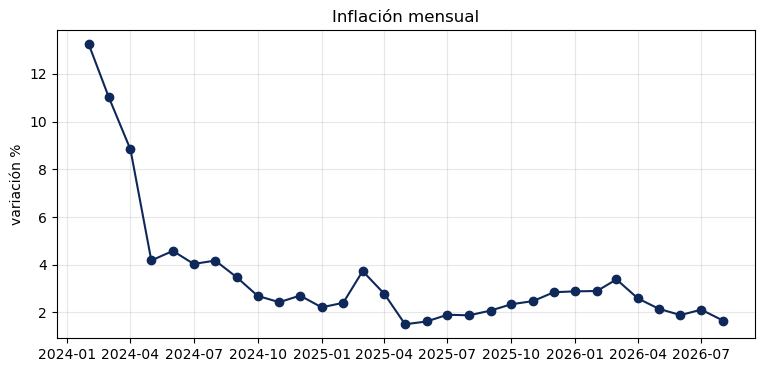

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ipc["fecha"], ipc["var_mensual"], marker="o", color="#0F285A")
ax.set_title("Inflación mensual")
ax.set_ylabel("variación %")
ax.grid(alpha=0.3)
plt.show()

Hasta acá la tarea fue directa y es porque alguien se tomó el trabajo de publicar la serie en un formato estable. Eso es una API.

Para muchas fuentes conocidas ya existe una biblioteca que arma el pedido por nosotros. Para el Banco Mundial, por ejemplo, está `wbdata`. Por debajo hace exactamente lo que acabamos de hacer.

## 3. Web scraping

Ahora al revés. Queremos los títulos de la portada de un diario, que nadie publicó en ningún formato ordenado. Están adentro del HTML de la página, mezclados con todo lo demás.

El primer paso es el mismo que antes, pedir la página. Lo que cambia es que la respuesta no es un JSON prolijo sino el código de la página entera.

In [13]:
from bs4 import BeautifulSoup
from pathlib import Path

ENCABEZADO = {"User-Agent": "Mozilla/5.0"}


def bajar_portada(url, respaldo):
    """Devuelve el HTML del sitio, o el de la copia guardada si el sitio no responde."""
    try:
        r = requests.get(url, headers=ENCABEZADO, timeout=15)
        r.raise_for_status()
        return r.text
    except Exception as e:
        print("No respondió el sitio, uso la copia guardada:", type(e).__name__)
        return Path(respaldo).read_text(encoding="utf-8")


# Las copias de respaldo en datos/ son del 7 de octubre de 2026. Si la portada en vivo ya no
# tiene la noticia del partido, pasar el respaldo como primer argumento para usarlo siempre.
html = bajar_portada("https://www.ambito.com/", "datos/portada_ambito_respaldo.html")

len(html)

398969

Son cientos de miles de caracteres de HTML. `BeautifulSoup` lo convierte en algo que se puede
recorrer buscando etiquetas.

En casi todos los diarios los títulos de la portada están dentro de etiquetas `<h2>`. Eso no
está documentado en ningún lado: se descubre mirando el código de la página con el inspector
del navegador.

In [14]:
soup = BeautifulSoup(html, "html.parser")

titulares = soup.find_all(["h2", "h3"])

print(len(titulares))
titulares[0]

158


<h3 class="drop-down-menu__subscription-plans-obj-title"> SUMATE A LA COMUNIDAD DE ÁMBITO        </h3>

`find_all` devuelve las etiquetas enteras, con el HTML adentro. `get_text` se queda solo con el
texto.

Filtramos los muy cortos porque suelen ser secciones ("Economía", "Deportes") y no títulos.

In [15]:
textos = [t.get_text(strip=True) for t in titulares]
textos = [t for t in textos if len(t) > 25]

ambito = pd.DataFrame({"titular": textos}).drop_duplicates()

print(ambito.shape)
ambito.head()

(137, 1)


,titular
0,SUMATE A LA COMUNIDAD DE ÁMBITO
1,"El dólar oficial amagó con rebotar, pero cerró..."
2,"Los ADRs borran subas iniciales, pero el riesg..."
3,¿En riesgo la privatización de AySA? El Gobier...
4,Jorge Macri renueva la gestión política de la ...


Comparar con la API es el punto de todo el bloque. Allá pedimos una serie y vino una serie. Acá
tuvimos que averiguar que los títulos están en `<h2>`, limpiar el texto y descartar los que no
servían.

Y nada garantiza que mañana siga funcionando. Si el diario rediseña la portada, este código deja
de andar y nadie nos avisa.

## 4. Contar menciones: el partido y el sponsor

Antes de hacer nada sofisticado con el texto, lo más simple que se puede medir es cuántas veces
aparece algo. Y sirve para mucho.

Ayer fue el último partido de Messi con la Selección, así que la portada de hoy es un caso
cómodo para ver si el método detecta un evento que sabemos que ocurrió.

In [16]:
def menciona(df, palabra):
    return df["titular"].str.lower().str.contains(palabra.lower())


print("titulares en la portada:", len(ambito))
print("mencionan a Messi:     ", menciona(ambito, "messi").sum())

ambito[menciona(ambito, "messi")].head()

titulares en la portada: 137
mencionan a Messi:      7


,titular
100,¿Messi por Evita? Un proyecto busca cambiar la...
101,El gol de Lionel Messi a Benín en su despedida...
102,Las imágenes de la despedida de Messi de la Se...
103,El curioso corte de pelo que se hizo el Dibu M...
104,"""Gracias Argentina"": el mensaje de Lionel Mess..."


El evento se detecta sin esfuerzo. Ahora la pregunta interesante.

Sancor Seguros es sponsor oficial de la AFA desde 2012, y renovó el acuerdo de cara al Mundial
2026. Pagó por estar presente en ese partido. Veamos si aparece.

In [17]:
print("mencionan a Sancor:", menciona(ambito, "sancor").sum())

# tambien en el HTML completo, no solo en los titulos
print("veces que aparece 'sancor' en toda la pagina:", html.lower().count("sancor"))

mencionan a Sancor: 0
veces que aparece 'sancor' en toda la pagina: 0


In [18]:
print("mencionan a Tapia:", menciona(ambito, "tapia").sum())

# tambien en el HTML completo, no solo en los titulos
print("veces que aparece 'tapia' en toda la pagina:", html.lower().count("tapia"))

mencionan a Tapia: 0
veces que aparece 'tapia' en toda la pagina: 0


Cero por los dos lados.

El evento que el sponsor auspició está en todas partes, y el sponsor no está en ninguna. No es que el método falle: está midiendo bien lo que mide, que es **la atención editorial**. La exposición comercial es otra cosa y vive en otro lado, en los minutos de cámara y en las
imágenes del estadio.

Si alguien quisiera medir cuánto valió ese auspicio, estos datos no le sirven, por más que sean masivos y gratis. Haría falta otra fuente.

El mismo evento, en otro diario. Olé es deportivo, así que la cobertura debería ser distinta.

In [19]:
html_ole = bajar_portada("https://www.ole.com.ar/", "datos/portada_ole_respaldo.html")

soup_ole = BeautifulSoup(html_ole, "html.parser")                       # mismo procedimiento que arriba
textos_ole = [t.get_text(strip=True) for t in soup_ole.find_all(["h2", "h3"])]
ole = pd.DataFrame({"titular": [t for t in textos_ole if len(t) > 25]}).drop_duplicates()

for nombre, d in [("Ámbito", ambito), ("Olé", ole)]:
    n = menciona(d, "messi").sum()
    print(f"{nombre:8s} {n:3d} de {len(d):3d} titulares  ({n / len(d):.0%})")

Ámbito     7 de 137 titulares  (5%)
Olé       29 de 147 titulares  (20%)



Olé       30 de 147 titulares  (20%)


Mismo día, mismo partido, y Olé le dedica varias veces más portada que Ámbito.

Si alguien midiera la importancia del evento contando titulares, le daría un número muy distinto según qué diario hubiera elegido. El número no mide el evento, mide lo que al diario le importa.

## 5. Un índice de sentimiento

Tenemos texto. Para convertirlo en un número, la forma más simple es contar palabras de una lista de positivas y una de negativas, y restar.

Esto se llama análisis de sentimiento por léxico. Hay herramientas hechas que traen listas mucho más grandes, como VADER. Lo armamos a mano porque así se ve exactamente de dónde sale el número.

In [20]:
POSITIVAS = {
    "sube", "suben", "subió", "subieron", "crece", "crecen", "creció", "crecimiento",
    "mejora", "mejoró", "mejoran", "repunta", "repuntó", "récord", "acuerdo", "acuerdos",
    "avanza", "avanzó", "gana", "ganó", "ganancia", "recupera", "recuperó", "recuperación",
    "superávit", "impulso", "aumento", "aumenta", "aumentó", "inversión", "inversiones",
    "acelera", "aceleró", "expansión", "alza", "beneficio", "reactivación", "auge",
    "optimismo", "confianza",
}

NEGATIVAS = {
    "cae", "caen", "cayó", "cayeron", "caída", "caídas", "crisis", "déficit", "desplome",
    "desplomó", "desplomaron", "pierde", "perdió", "pérdida", "pérdidas", "retrocede",
    "retrocedió", "retroceso", "conflicto", "paro", "despidos", "cierre", "cierra", "cierran",
    "deuda", "ajuste", "riesgo", "tensión", "freno", "frena", "frenó", "preocupación",
    "derrumbe", "derrumbó", "baja", "bajan", "bajó", "recesión", "inflación", "atraso",
    "desempleo", "pobreza", "default", "incertidumbre", "advertencia", "alerta",
}

Para contar hay que normalizar: pasar a minúsculas y sacar la puntuación, así "cayó." y "cayó"
son la misma palabra.

In [21]:
import unicodedata


def puntaje(titular):
    palabras = "".join(c if c.isalnum() or c.isspace() else " " for c in titular.lower()).split()
    return sum(p in POSITIVAS for p in palabras) - sum(p in NEGATIVAS for p in palabras)


def clasificar(p):
    return "positivo" if p > 0 else ("negativo" if p < 0 else "neutro")


ambito["puntaje"] = ambito["titular"].apply(puntaje)
ambito["tono"] = ambito["puntaje"].apply(clasificar)

ambito[ambito["puntaje"] != 0].head(10)

,titular,puntaje,tono
1,"El dólar oficial amagó con rebotar, pero cerró...",-1,negativo
2,"Los ADRs borran subas iniciales, pero el riesg...",-1,negativo
3,¿En riesgo la privatización de AySA? El Gobier...,-1,negativo
5,Fed: crece el contexto entre sus miembros sobr...,1,positivo
9,Jubilados que alquilan: el fenómeno crece en A...,1,positivo
11,Pánico financiero en Francia: sus bonos se hun...,-1,negativo
17,Santa Fe Bio y TotalEnergies firman acuerdo pa...,1,positivo
18,Por qué los mercados están en alza y bajo presión,1,positivo
24,"Mercados: el dólar bajó por segundo día, mient...",-2,negativo
25,"Cedears: tasas récord, euforia por la IA y Bra...",1,positivo


El índice del día es el promedio de los puntajes. Positivo quiere decir que en la portada hubo
más palabras de nuestra lista buena que de la mala.

In [22]:
print(ambito["tono"].value_counts())
print("índice del día:", round(ambito["puntaje"].mean(), 3))

tono
neutro      102
negativo     18
positivo     17
Name: count, dtype: int64
índice del día: -0.015


## 6. Lo mismo con otros diarios

La pregunta que cierra la clase es si el índice mide el humor económico o mide el diario.
La forma de averiguarlo es repetir todo con otras portadas.

Agregamos una columna de cobertura, que es el porcentaje de títulos donde la lista encontró al menos una palabra. Conviene mirarla antes que el índice: si la cobertura es baja, el índice se está calculando sobre unos pocos títulos.

In [23]:
def indice_del_diario(url, respaldo):
    html = bajar_portada(url, respaldo)
    soup = BeautifulSoup(html, "html.parser")
    textos = [t.get_text(strip=True) for t in soup.find_all(["h2", "h3"])]
    textos = [t for t in textos if len(t) > 25]

    d = pd.DataFrame({"titular": textos}).drop_duplicates()
    d["puntaje"] = d["titular"].apply(puntaje)
    d["tono"] = d["puntaje"].apply(clasificar)
    return d


diarios = {
    "Ámbito": ("https://www.ambito.com/", "datos/portada_ambito_respaldo.html"),
    "La Nación, economía": ("https://www.lanacion.com.ar/economia/",
                            "datos/portada_lanacion_economia_respaldo.html"),
    "El Cronista": ("https://www.cronista.com/economia-politica/",
                    "datos/portada_cronista_respaldo.html"),
}

resumen = []
for nombre, (url, respaldo) in diarios.items():
    d = indice_del_diario(url, respaldo)
    con_palabras = (d["puntaje"] != 0).sum()
    resumen.append({
        "diario": nombre,
        "titulares": len(d),
        "cobertura": f"{con_palabras / len(d):.0%}",
        "positivos": (d["tono"] == "positivo").sum(),
        "negativos": (d["tono"] == "negativo").sum(),
        "indice": round(d["puntaje"].mean(), 3),
        "Messi": menciona(d, "messi").sum(),
        "Sancor": menciona(d, "sancor").sum(),
    })

pd.DataFrame(resumen)

,diario,titulares,cobertura,positivos,negativos,indice,Messi,Sancor
0,Ámbito,137,26%,17,18,-0.015,7,0
1,"La Nación, economía",58,21%,7,5,0.017,0,0
2,El Cronista,20,30%,4,2,0.100,0,0


## Para repasar

Si los dos índices dan distinto, hay por lo menos tres explicaciones y el número no distingue entre ellas:

1. Los diarios cubren noticias distintas.
2. Los diarios cubren las mismas noticias con palabras distintas.
3. Nuestra lista de palabras le pega mejor al vocabulario de uno que al del otro.

Y no tenemos contra qué chequearlo, porque no existe un "humor económico verdadero" publicado en ningún lado.

Esa es exactamente la diferencia con Cavallo. Él se tomó el trabajo de construir la medición cara, mandando 323 personas a los locales, para poder decir si la barata servía. Nosotros construimos una medición barata y no tenemos con qué validarla.